# Correlation between D8 LFC and D20 LFC  
**reminder: iSTOP & U1 in the library now**  
Good CRISPR screen should have high correlation  
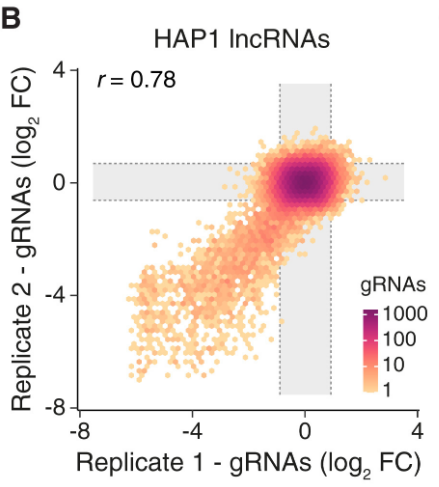

In [1]:
import pandas as pd
import pyranges as pr
from Bio import SeqIO
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
from matplotlib import font_manager
import re

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import re

In [2]:
# remove negative controls that can be mapped to the genome (with bowtie)
mapped_ctrl_path = "/media/scratch/fy2306/projects/base_editing/data/bowtie/all/all_sgrna_seqs.bowtie_hg38.processed.tsv"
mapped_ctrl_df = pd.read_csv(mapped_ctrl_path, sep="\t")
mapped_ctrl_df = mapped_ctrl_df[
    mapped_ctrl_df['id'].str.startswith(('Random', 'Non-targeting-controls', 'AAVS1'))
    & ~(mapped_ctrl_df['id'].str.startswith('AAVS1') & (mapped_ctrl_df['Alignments_NM0'] == 1) & (mapped_ctrl_df['Alignments_NM1'] == 0))
]
mapped_ctrl_list = mapped_ctrl_df["id"].tolist()
print(len(mapped_ctrl_list))
all_ctrl = [
    record.id for record in SeqIO.parse("/media/scratch/fy2306/projects/base_editing/data/bowtie/negative_controls/input/negative_controls.fa", "fasta")
    ]
clean_ctrl_list = list(set(all_ctrl)-set(mapped_ctrl_list))
print(len(clean_ctrl_list))
print(len(all_ctrl))

91
474
565


In [3]:
# randomly group nc sgrnas
def group_and_aggregate(df, group_size, random_state=None):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    num_groups = len(df_shuffled) // group_size
    df_trimmed = df_shuffled.iloc[:num_groups * group_size]
    
    grouped = np.array_split(df_trimmed, num_groups)
    
    aggregated = []
    for group in grouped:
        sgrna_concat = ','.join(group['sgrna'].astype(str))
        avg_lfc = group['per time unit LFC'].mean()
        aggregated.append({
            'sgrna': sgrna_concat,
            'per time unit LFC': avg_lfc
        })
    
    return pd.DataFrame(aggregated)

In [4]:
def negative_control_shift(		
		date,
		nc_test_name,
		win_size,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate, per_time_unit=True):

	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	df_nc = df_nc[['sgrna', 'per time unit LFC']]

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	
	return nc_combined_median_value

In [5]:
id_prefix_list = [
	"MYC_GFP_"
]

def corr_d8_d20_nucleotide_LFC(gene_summary_path, title, xlabel, ylabel, xlabel_x, ylabel_y, dayx, dayy, xlim, ylim, xticks, yticks, nc_combined_median_value=None, exclude_repeats=False, sig_only=False):
	df = pd.read_csv(gene_summary_path, sep="\t")
	# preprocess
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df = df[df['id'].str.match(pattern)]
	edited_pos_chr_col = "nucleotide_pos"
	df[edited_pos_chr_col] = df['id'].str.extract(pattern)[1].astype(int)
	x_col = f"{xlabel}_vs_Cas9-HMOI_D0|neg|lfc"
	y_col = f"{ylabel}_vs_Cas9-HMOI_D0|neg|lfc"
	df[x_col] = df[x_col] / (dayx + 0)
	df[y_col] = df[y_col] / (dayy + 0)

	# revision: exclude repeats and only include significant basepairs
	df_lib = pd.read_csv("/media/scratch/fy2306/projects/base_editing/results/20250416/nucleotide_negLFC_timeunit_mean_4.tsv", sep="\t")
	df_lib["significant"] = (df_lib["fdr"] < 0.05) & (df_lib["direction"] == True) & (df_lib['indel_repeats'] == False)
	if exclude_repeats:
		df = df[~df[edited_pos_chr_col].isin(df_lib[df_lib["indel_repeats"] == True][edited_pos_chr_col])]
	if sig_only:
		df = df[df[edited_pos_chr_col].isin(df_lib[df_lib["significant"] == True][edited_pos_chr_col])]
	# skip nc_combined_median_value
	# we only use nc_combined_median_value to shift when merging all four replicates together
	r, p = pearsonr(df[x_col], df[y_col])
	# r, p = spearmanr(merged_df["LFC_d8"], merged_df["LFC_d20"])

	print(f"Total number of basepairs: {len(df)}")

	fig, ax = plt.subplots(figsize=(4, 4))

	hb = ax.hexbin(
		x=df[x_col],
		y=df[y_col],
		gridsize=50,      
		cmap="flare",     
		mincnt=1,
		vmin = 1           
	)

	cax = ax.inset_axes([0.7, 0.15, 0.3, 0.025])

	cb = plt.colorbar(hb, cax=cax, orientation='horizontal')
	cb.set_label("bp count", fontsize=10)
	cb.ax.tick_params(labelsize=10)

	sns.despine(ax=ax, top=True, right=True)
	ax.set_xlim(xlim)
	ax.set_ylim(ylim)
	ax.set_xticks(xticks)
	ax.set_yticks(yticks)
	ax.tick_params(labelsize=12)
	ax.set_xlabel(xlabel_x, fontsize=12)
	ax.set_ylabel(ylabel_y, fontsize=12)
	ax.set_title(title, fontsize=12)
	ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
	ax.axvline(x=0, color='black', linestyle='--', linewidth=0.5)

	ax.text(
		0.05, 0.98,
		f"r = {r:.2f}",
		transform=ax.transAxes,
		fontsize=12,
		verticalalignment='top',
		horizontalalignment='left'
	)

	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)

	plt.tight_layout()

	if exclude_repeats:
		plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/screening/basepair_lfc_sample_corr.{xlabel}_vs_{ylabel}.exclude_repeats.png", 
					bbox_inches="tight",
					dpi=300,              
					transparent=True,
					format='png')
	elif sig_only:
		plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/screening/basepair_lfc_sample_corr.{xlabel}_vs_{ylabel}.sig_only.png", 
					bbox_inches="tight",
					dpi=300,              
					transparent=True,
					format='png')
	else:
		plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/screening/basepair_lfc_sample_corr.{xlabel}_vs_{ylabel}.pdf", 
					bbox_inches="tight",
					dpi=300,              
					transparent=True,
					format='pdf')
	
	plt.show()

565
Total number of basepairs: 10055


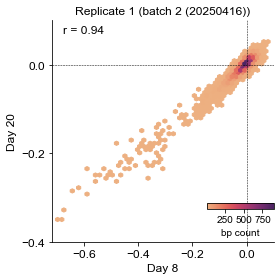

Total number of basepairs: 9225


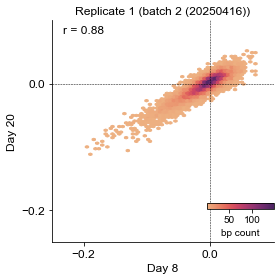

Total number of basepairs: 343


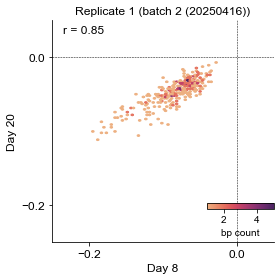

Total number of basepairs: 10055


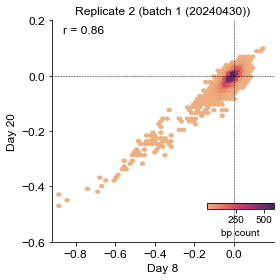

Total number of basepairs: 9225


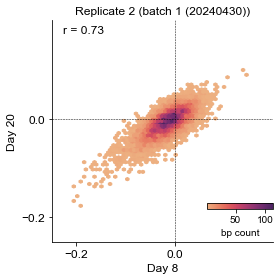

Total number of basepairs: 343


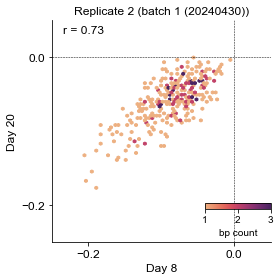

Total number of basepairs: 10055


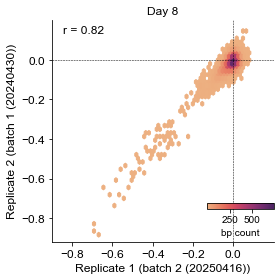

Total number of basepairs: 9225


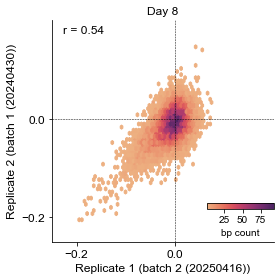

Total number of basepairs: 343


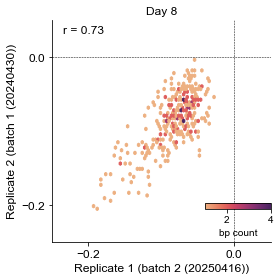

Total number of basepairs: 10055


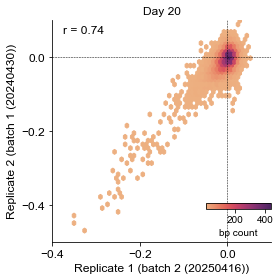

Total number of basepairs: 9225


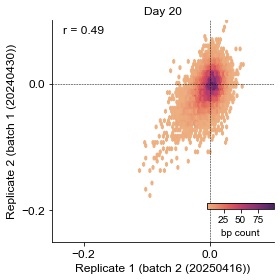

Total number of basepairs: 343


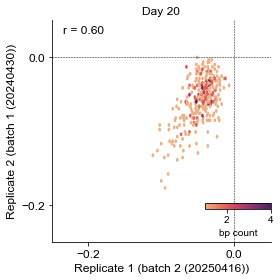

In [6]:
date = "20250416"
nc_test_name = "test-1-standard/test"
win_size = "4"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
merge_method_replicate = "mean"
nc_combined_median_value = negative_control_shift(		
		date,
		nc_test_name,
		win_size,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate, per_time_unit=True)

corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Replicate 1 (batch 2 (20250416))", 
	xlabel = "Cas9-LMOI_D8", 
	ylabel = "Cas9-LMOI_D20", 
	xlabel_x = "Day 8",
	ylabel_y = "Day 20",
	dayx = 8, 
	dayy = 20,
	ylim = (-0.4, 0.1),
	xlim = (-0.72, 0.1),
	yticks = [-0.4, -0.2, 0],
	xticks = [-0.6, -0.4, -0.2, 0],
	nc_combined_median_value = nc_combined_median_value)
corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Replicate 1 (batch 2 (20250416))", 
	xlabel = "Cas9-LMOI_D8", 
	ylabel = "Cas9-LMOI_D20", 
	xlabel_x = "Day 8",
	ylabel_y = "Day 20",
	dayx = 8, 
	dayy = 20,
	ylim = (-0.25, 0.1),
	xlim = (-0.25, 0.1),
	yticks = [-0.2, 0],
	xticks = [-0.2, 0],
	nc_combined_median_value = nc_combined_median_value,
	exclude_repeats=True)
corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Replicate 1 (batch 2 (20250416))", 
	xlabel = "Cas9-LMOI_D8", 
	ylabel = "Cas9-LMOI_D20", 
	xlabel_x = "Day 8",
	ylabel_y = "Day 20",
	dayx = 8, 
	dayy = 20,
	ylim = (-0.25, 0.05),
	xlim = (-0.25, 0.05),
	yticks = [-0.2, 0],
	xticks = [-0.2, 0],
	nc_combined_median_value = nc_combined_median_value,
	sig_only=True)

corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Replicate 2 (batch 1 (20240430))", 
	xlabel = "Cas9_SpRY_L_MOI_D_8", 
	ylabel = "Cas9_SpRY_L_MOI_D_20", 
	xlabel_x = "Day 8",
	ylabel_y = "Day 20",
	dayx = 8, 
	dayy = 20,
	ylim = (-0.6, 0.2),
	xlim = (-0.92, 0.2),
	yticks = [-0.6, -0.4, -0.2, 0, 0.2],
	xticks = [-0.8, -0.6, -0.4, -0.2, 0],
	nc_combined_median_value = nc_combined_median_value)
corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Replicate 2 (batch 1 (20240430))", 
	xlabel = "Cas9_SpRY_L_MOI_D_8", 
	ylabel = "Cas9_SpRY_L_MOI_D_20", 
	xlabel_x = "Day 8",
	ylabel_y = "Day 20",
	dayx = 8, 
	dayy = 20,
	ylim = (-0.25, 0.2),
	xlim = (-0.25, 0.2),
	yticks = [-0.2, 0],
	xticks = [-0.2, 0],
	nc_combined_median_value = nc_combined_median_value,
	exclude_repeats=True)
corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Replicate 2 (batch 1 (20240430))", 
	xlabel = "Cas9_SpRY_L_MOI_D_8", 
	ylabel = "Cas9_SpRY_L_MOI_D_20", 
	xlabel_x = "Day 8",
	ylabel_y = "Day 20",
	dayx = 8, 
	dayy = 20,
	ylim = (-0.25, 0.05),
	xlim = (-0.25, 0.05),
	yticks = [-0.2, 0],
	xticks = [-0.2, 0],
	nc_combined_median_value = nc_combined_median_value,
	sig_only=True)

corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Day 8", 
	xlabel = "Cas9-LMOI_D8", 
	ylabel = "Cas9_SpRY_L_MOI_D_8", 
	xlabel_x = "Replicate 1 (batch 2 (20250416))",
	ylabel_y = "Replicate 2 (batch 1 (20240430))",
	dayx = 8, 
	dayy = 8,
	ylim = (-0.92, 0.2),
	xlim = (-0.9, 0.2),
	yticks = [-0.8, -0.6, -0.4, -0.2, 0],
	xticks = [-0.8, -0.6, -0.4, -0.2, 0],
	nc_combined_median_value = nc_combined_median_value)
corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Day 8", 
	xlabel = "Cas9-LMOI_D8", 
	ylabel = "Cas9_SpRY_L_MOI_D_8", 
	xlabel_x = "Replicate 1 (batch 2 (20250416))",
	ylabel_y = "Replicate 2 (batch 1 (20240430))",
	dayx = 8, 
	dayy = 8,
	ylim = (-0.25, 0.2),
	xlim = (-0.25, 0.2),
	yticks = [-0.2, 0],
	xticks = [-0.2, 0],
	nc_combined_median_value = nc_combined_median_value,
	exclude_repeats=True)
corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Day 8", 
	xlabel = "Cas9-LMOI_D8", 
	ylabel = "Cas9_SpRY_L_MOI_D_8", 
	xlabel_x = "Replicate 1 (batch 2 (20250416))",
	ylabel_y = "Replicate 2 (batch 1 (20240430))",
	dayx = 8, 
	dayy = 8,
	ylim = (-0.25, 0.05),
	xlim = (-0.25, 0.05),
	yticks = [-0.2, 0],
	xticks = [-0.2, 0],
	nc_combined_median_value = nc_combined_median_value,
	sig_only=True)

corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Day 20", 
	xlabel = "Cas9-LMOI_D20", 
	ylabel = "Cas9_SpRY_L_MOI_D_20", 
	xlabel_x = "Replicate 1 (batch 2 (20250416))",
	ylabel_y = "Replicate 2 (batch 1 (20240430))",
	dayx = 20, 
	dayy = 20,
	ylim = (-0.5, 0.1),
	xlim = (-0.4, 0.1),
	yticks = [-0.4, -0.2, 0],
	xticks = [-0.4, -0.2, 0],
	nc_combined_median_value = nc_combined_median_value)
corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Day 20", 
	xlabel = "Cas9-LMOI_D20", 
	ylabel = "Cas9_SpRY_L_MOI_D_20", 
	xlabel_x = "Replicate 1 (batch 2 (20250416))",
	ylabel_y = "Replicate 2 (batch 1 (20240430))",
	dayx = 20, 
	dayy = 20,
	ylim = (-0.25, 0.1),
	xlim = (-0.25, 0.1),
	yticks = [-0.2, 0],
	xticks = [-0.2, 0],
	nc_combined_median_value = nc_combined_median_value,
	exclude_repeats=True)
corr_d8_d20_nucleotide_LFC(
	gene_summary_path = "/media/scratch/fy2306/projects/base_editing/data/20250416/mageck/test-1-standard-nucleotide/test/mean/myc_repeats/4/MYC_U1.gene_summary.txt", 
	title = "Day 20", 
	xlabel = "Cas9-LMOI_D20", 
	ylabel = "Cas9_SpRY_L_MOI_D_20", 
	xlabel_x = "Replicate 1 (batch 2 (20250416))",
	ylabel_y = "Replicate 2 (batch 1 (20240430))",
	dayx = 20, 
	dayy = 20,
	ylim = (-0.25, 0.05),
	xlim = (-0.25, 0.05),
	yticks = [-0.2, 0],
	xticks = [-0.2, 0],
	nc_combined_median_value = nc_combined_median_value,
	sig_only=True)